# Rede neural implementada manualmente com NumPy

**Disciplina:** Matemática para Ciência de Dados  
**Integrante:** Bruno Aparecido Barbosa  
**Data:** 26/09/2026

## Objetivo

Neste notebook implementamos manualmente uma rede neural `30–16–8–1` para classificar tumores de mama como malignos ou benignos. A proposta é detalhar as etapas que o Keras realiza internamente: propagação para frente, cálculo da perda, retropropagação dos gradientes e atualização dos pesos em mini-batches.

Usamos a mesma base, a mesma separação e a mesma padronização do notebook com Keras. Assim, as duas implementações podem ser comparadas de maneira mais justa.

## 1. Bibliotecas e semente aleatória

A implementação da rede usa apenas NumPy. O `scikit-learn` será utilizado para carregar e preparar os dados, enquanto Matplotlib e Seaborn serão usados nos gráficos.

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import Markdown, display
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEMENTE = 42
random.seed(SEMENTE)
np.random.seed(SEMENTE)
sns.set_theme(style="whitegrid")

## 2. Preparação dos dados

A variável-alvo contém `0` para tumores malignos e `1` para tumores benignos. Reservamos 20% da base para teste e 20% dos dados restantes para validação. O padronizador é ajustado somente com o conjunto de treino.

In [2]:
dados = load_breast_cancer(as_frame=True)
X = dados.data
y = dados.target

X_treino_completo, X_teste, y_treino_completo, y_teste = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEMENTE,
    stratify=y,
)

X_treino, X_validacao, y_treino, y_validacao = train_test_split(
    X_treino_completo,
    y_treino_completo,
    test_size=0.20,
    random_state=SEMENTE,
    stratify=y_treino_completo,
)

padronizador = StandardScaler()
X_treino_pad = padronizador.fit_transform(X_treino)
X_validacao_pad = padronizador.transform(X_validacao)
X_teste_pad = padronizador.transform(X_teste)

y_treino_np = y_treino.to_numpy().reshape(-1, 1)
y_validacao_np = y_validacao.to_numpy().reshape(-1, 1)
y_teste_np = y_teste.to_numpy().reshape(-1, 1)

print(f"Treino: {X_treino_pad.shape}")
print(f"Validação: {X_validacao_pad.shape}")
print(f"Teste: {X_teste_pad.shape}")

Treino: (364, 30)
Validação: (91, 30)
Teste: (114, 30)


## 3. Fluxo matemático da rede

Na propagação para frente, cada camada calcula uma combinação linear e aplica sua função de ativação. Na retropropagação, o caminho é percorrido no sentido contrário para calcular como cada peso contribuiu para o erro.

As setas escuras na figura representam o *forward*. As setas vermelhas representam os gradientes calculados no *backward*.

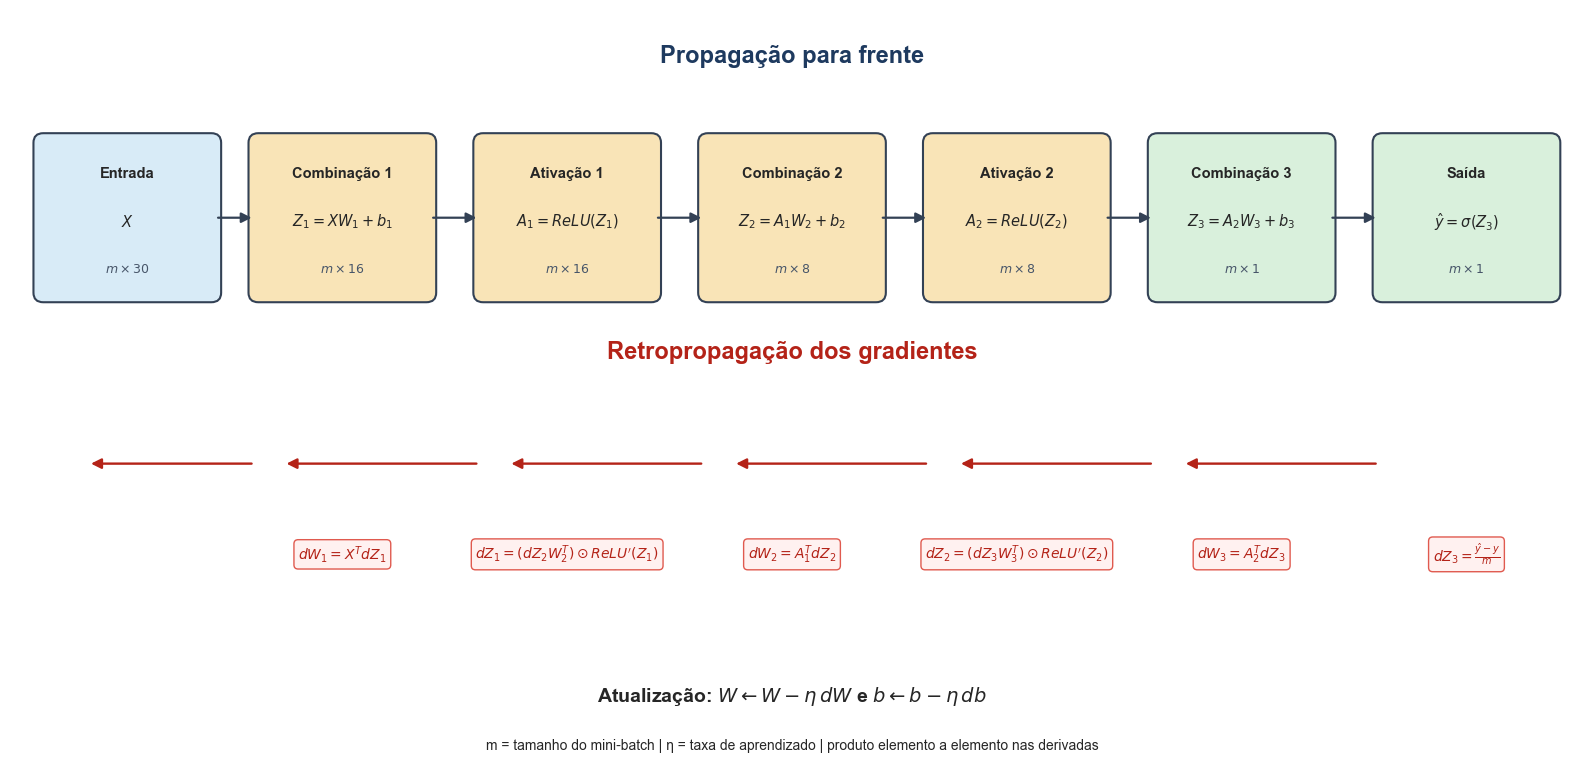

In [3]:
def desenhar_fluxo_manual(caminho="fluxo_rede_manual.png"):
    fig, ax = plt.subplots(figsize=(16, 8))
    ax.set_xlim(0, 16)
    ax.set_ylim(0, 8)
    ax.axis("off")

    etapas = [
        (0.3, "Entrada", "$X$", "$m \\times 30$", "#d8ebf7"),
        (2.5, "Combinação 1", "$Z_1=XW_1+b_1$", "$m \\times 16$", "#f9e4b7"),
        (4.8, "Ativação 1", "$A_1=ReLU(Z_1)$", "$m \\times 16$", "#f9e4b7"),
        (7.1, "Combinação 2", "$Z_2=A_1W_2+b_2$", "$m \\times 8$", "#f9e4b7"),
        (9.4, "Ativação 2", "$A_2=ReLU(Z_2)$", "$m \\times 8$", "#f9e4b7"),
        (11.7, "Combinação 3", "$Z_3=A_2W_3+b_3$", "$m \\times 1$", "#d9f0dc"),
        (14.0, "Saída", "$\\hat{y}=\\sigma(Z_3)$", "$m \\times 1$", "#d9f0dc"),
    ]

    largura = 1.8
    altura = 1.65
    y_frente = 5.0

    for x0, titulo, formula, dimensao, cor in etapas:
        caixa = FancyBboxPatch(
            (x0, y_frente),
            largura,
            altura,
            boxstyle="round,pad=0.06,rounding_size=0.1",
            facecolor=cor,
            edgecolor="#334155",
            linewidth=1.5,
        )
        ax.add_patch(caixa)
        ax.text(x0 + largura / 2, y_frente + 1.28, titulo, ha="center", va="center", fontsize=10.5, weight="bold")
        ax.text(x0 + largura / 2, y_frente + 0.78, formula, ha="center", va="center", fontsize=10.5)
        ax.text(x0 + largura / 2, y_frente + 0.28, dimensao, ha="center", va="center", fontsize=9, color="#475569")

    for i in range(len(etapas) - 1):
        x_inicio = etapas[i][0] + largura
        x_fim = etapas[i + 1][0]
        seta = FancyArrowPatch(
            (x_inicio, y_frente + altura / 2),
            (x_fim, y_frente + altura / 2),
            arrowstyle="-|>",
            mutation_scale=15,
            linewidth=1.6,
            color="#334155",
        )
        ax.add_patch(seta)

    ax.text(8, 7.45, "Propagação para frente", ha="center", fontsize=17, weight="bold", color="#1e3a5f")
    ax.text(8, 4.35, "Retropropagação dos gradientes", ha="center", fontsize=17, weight="bold", color="#b42318")

    gradientes = [
        (14.9, "$dZ_3=\\frac{\\hat{y}-y}{m}$"),
        (12.6, "$dW_3=A_2^T dZ_3$"),
        (10.3, "$dZ_2=(dZ_3W_3^T)\\odot ReLU'(Z_2)$"),
        (8.0, "$dW_2=A_1^T dZ_2$"),
        (5.7, "$dZ_1=(dZ_2W_2^T)\\odot ReLU'(Z_1)$"),
        (3.4, "$dW_1=X^T dZ_1$"),
    ]

    y_grad = 2.3
    for x0, formula in gradientes:
        ax.text(
            x0,
            y_grad,
            formula,
            ha="center",
            va="center",
            fontsize=10,
            color="#b42318",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#fff1f0", edgecolor="#e05a4f"),
        )

    for x_direita, x_esquerda in [(14.0, 12.0), (11.7, 9.7), (9.4, 7.4), (7.1, 5.1), (4.8, 2.8), (2.5, 0.8)]:
        seta = FancyArrowPatch(
            (x_direita, 3.25),
            (x_esquerda, 3.25),
            arrowstyle="-|>",
            mutation_scale=15,
            linewidth=1.7,
            color="#b42318",
        )
        ax.add_patch(seta)

    ax.text(
        8,
        0.75,
        r"Atualização: $W \leftarrow W-\eta\,dW$ e $b \leftarrow b-\eta\,db$",
        ha="center",
        fontsize=14,
        weight="bold",
    )
    ax.text(8, 0.25, "m = tamanho do mini-batch | η = taxa de aprendizado | produto elemento a elemento nas derivadas", ha="center", fontsize=10)

    plt.tight_layout()
    plt.savefig(caminho, dpi=180, bbox_inches="tight")
    plt.show()


desenhar_fluxo_manual()

## 4. Funções de ativação e perda

A ReLU mantém valores positivos e zera valores negativos. Sua derivada vale 1 para entradas positivas e 0 para entradas negativas. A sigmoide transforma a saída em uma probabilidade. Para medir o erro usamos a entropia cruzada binária.

$$ReLU(z)=\max(0,z)$$

$$\sigma(z)=\frac{1}{1+e^{-z}}$$

$$L=-\frac{1}{m}\sum\left[y\log(\hat{y})+(1-y)\log(1-\hat{y})\right]$$

In [4]:
def relu(z):
    return np.maximum(0, z)


def derivada_relu(z):
    return (z > 0).astype(float)


def sigmoid(z):
    z_seguro = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z_seguro))


def entropia_cruzada(y_real, y_estimado):
    epsilon = 1e-12
    y_estimado = np.clip(y_estimado, epsilon, 1 - epsilon)
    return -np.mean(
        y_real * np.log(y_estimado)
        + (1 - y_real) * np.log(1 - y_estimado)
    )

## 5. Inicialização dos parâmetros

Os pesos das camadas ReLU usam a inicialização de He, que considera a quantidade de entradas de cada camada. Os vieses começam em zero.

As dimensões são:

- $W_1$: `30 × 16` e $b_1$: `1 × 16`;
- $W_2$: `16 × 8` e $b_2$: `1 × 8`;
- $W_3$: `8 × 1` e $b_3$: `1 × 1`.

In [5]:
def inicializar_parametros(semente=42):
    gerador = np.random.default_rng(semente)

    parametros = {
        "W1": gerador.normal(0, np.sqrt(2 / 30), size=(30, 16)),
        "b1": np.zeros((1, 16)),
        "W2": gerador.normal(0, np.sqrt(2 / 16), size=(16, 8)),
        "b2": np.zeros((1, 8)),
        "W3": gerador.normal(0, np.sqrt(1 / 8), size=(8, 1)),
        "b3": np.zeros((1, 1)),
    }
    return parametros


parametros_iniciais = inicializar_parametros(SEMENTE)
for nome, valor in parametros_iniciais.items():
    print(f"{nome}: {valor.shape}")

W1: (30, 16)
b1: (1, 16)
W2: (16, 8)
b2: (1, 8)
W3: (8, 1)
b3: (1, 1)


## 6. Propagação para frente

O *forward* recebe uma matriz com várias amostras. Cada linha percorre as duas camadas ReLU até chegar à saída sigmoide. Também guardamos resultados intermediários no `cache`, pois eles serão necessários no cálculo dos gradientes.

In [6]:
def forward(X_lote, parametros):
    Z1 = X_lote @ parametros["W1"] + parametros["b1"]
    A1 = relu(Z1)

    Z2 = A1 @ parametros["W2"] + parametros["b2"]
    A2 = relu(Z2)

    Z3 = A2 @ parametros["W3"] + parametros["b3"]
    A3 = sigmoid(Z3)

    cache = {
        "X": X_lote,
        "Z1": Z1,
        "A1": A1,
        "Z2": Z2,
        "A2": A2,
        "Z3": Z3,
        "A3": A3,
    }
    return A3, cache

## 7. Retropropagação

Começamos pelo erro da saída e aplicamos a regra da cadeia no sentido inverso. A combinação de sigmoide com entropia cruzada simplifica o primeiro gradiente para $(\hat{y}-y)/m$.

O operador `@` representa multiplicação de matrizes. As somas com `axis=0` calculam o gradiente dos vieses para todo o mini-batch.

In [7]:
def backward(y_lote, parametros, cache):
    m = y_lote.shape[0]

    dZ3 = (cache["A3"] - y_lote) / m
    dW3 = cache["A2"].T @ dZ3
    db3 = np.sum(dZ3, axis=0, keepdims=True)

    dA2 = dZ3 @ parametros["W3"].T
    dZ2 = dA2 * derivada_relu(cache["Z2"])
    dW2 = cache["A1"].T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = dZ2 @ parametros["W2"].T
    dZ1 = dA1 * derivada_relu(cache["Z1"])
    dW1 = cache["X"].T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    return {
        "dW1": dW1,
        "db1": db1,
        "dW2": dW2,
        "db2": db2,
        "dW3": dW3,
        "db3": db3,
    }


def atualizar_parametros(parametros, gradientes, taxa_aprendizado):
    for camada in (1, 2, 3):
        parametros[f"W{camada}"] -= taxa_aprendizado * gradientes[f"dW{camada}"]
        parametros[f"b{camada}"] -= taxa_aprendizado * gradientes[f"db{camada}"]

## 8. Treinamento em mini-batches

Em cada época embaralhamos os dados e criamos lotes de 16 amostras. Para cada lote executamos `forward`, `backward` e a atualização dos parâmetros.

Também implementamos uma parada antecipada simples. Guardamos a melhor versão dos pesos e interrompemos o treinamento se a perda de validação deixar de melhorar por 35 épocas.

In [8]:
def copiar_parametros(parametros):
    return {nome: valor.copy() for nome, valor in parametros.items()}


def calcular_acuracia(X_dados, y_real, parametros):
    probabilidades, _ = forward(X_dados, parametros)
    previsoes = (probabilidades >= 0.5).astype(int)
    return np.mean(previsoes == y_real)


def treinar_rede(
    X_treino,
    y_treino,
    X_validacao,
    y_validacao,
    epocas=500,
    tamanho_batch=16,
    taxa_aprendizado=0.02,
    paciencia=35,
    semente=42,
):
    parametros = inicializar_parametros(semente)
    gerador = np.random.default_rng(semente)

    historico = {
        "perda_treino": [],
        "perda_validacao": [],
        "acuracia_treino": [],
        "acuracia_validacao": [],
    }

    melhor_perda = np.inf
    melhores_parametros = copiar_parametros(parametros)
    epocas_sem_melhora = 0

    for epoca in range(epocas):
        indices = gerador.permutation(len(X_treino))
        X_embaralhado = X_treino[indices]
        y_embaralhado = y_treino[indices]

        for inicio in range(0, len(X_treino), tamanho_batch):
            fim = inicio + tamanho_batch
            X_lote = X_embaralhado[inicio:fim]
            y_lote = y_embaralhado[inicio:fim]

            _, cache = forward(X_lote, parametros)
            gradientes = backward(y_lote, parametros, cache)
            atualizar_parametros(parametros, gradientes, taxa_aprendizado)

        prob_treino, _ = forward(X_treino, parametros)
        prob_validacao, _ = forward(X_validacao, parametros)

        perda_treino = entropia_cruzada(y_treino, prob_treino)
        perda_validacao = entropia_cruzada(y_validacao, prob_validacao)

        historico["perda_treino"].append(perda_treino)
        historico["perda_validacao"].append(perda_validacao)
        historico["acuracia_treino"].append(calcular_acuracia(X_treino, y_treino, parametros))
        historico["acuracia_validacao"].append(calcular_acuracia(X_validacao, y_validacao, parametros))

        if perda_validacao < melhor_perda - 1e-5:
            melhor_perda = perda_validacao
            melhores_parametros = copiar_parametros(parametros)
            epocas_sem_melhora = 0
        else:
            epocas_sem_melhora += 1

        if epocas_sem_melhora >= paciencia:
            break

    return melhores_parametros, historico


TAMANHO_BATCH = 16
parametros, historico = treinar_rede(
    X_treino_pad,
    y_treino_np,
    X_validacao_pad,
    y_validacao_np,
    tamanho_batch=TAMANHO_BATCH,
)

atualizacoes_por_epoca = int(np.ceil(len(X_treino_pad) / TAMANHO_BATCH))
print(f"Atualizações por época: {atualizacoes_por_epoca}")
print(f"Épocas executadas: {len(historico['perda_treino'])}")

Atualizações por época: 23
Épocas executadas: 102


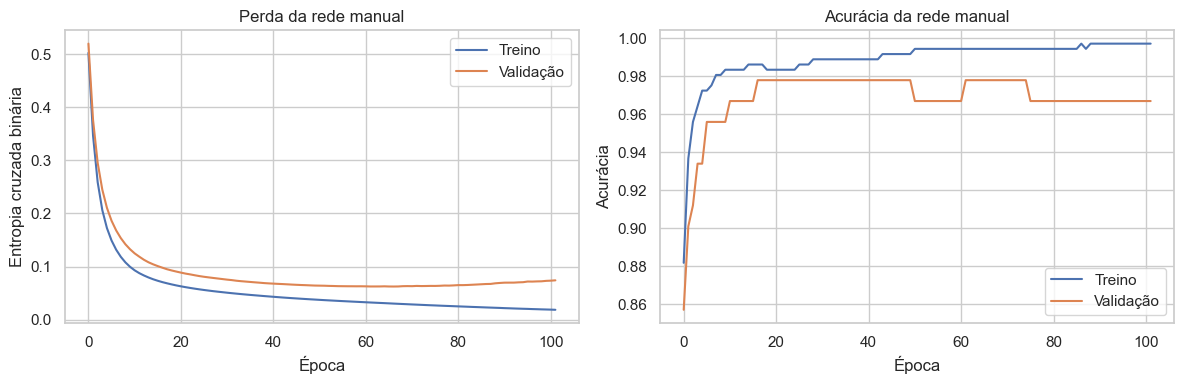

In [9]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 4))

eixos[0].plot(historico["perda_treino"], label="Treino")
eixos[0].plot(historico["perda_validacao"], label="Validação")
eixos[0].set_title("Perda da rede manual")
eixos[0].set_xlabel("Época")
eixos[0].set_ylabel("Entropia cruzada binária")
eixos[0].legend()

eixos[1].plot(historico["acuracia_treino"], label="Treino")
eixos[1].plot(historico["acuracia_validacao"], label="Validação")
eixos[1].set_title("Acurácia da rede manual")
eixos[1].set_xlabel("Época")
eixos[1].set_ylabel("Acurácia")
eixos[1].legend()

plt.tight_layout()
plt.savefig("historico_rede_manual.png", dpi=180, bbox_inches="tight")
plt.show()

## 9. Avaliação no teste

O teste é realizado somente depois que o treinamento e a escolha dos melhores pesos terminam. Usamos o limiar 0,5 para transformar probabilidades em classes.

In [10]:
probabilidades_teste, _ = forward(X_teste_pad, parametros)
previsoes_teste = (probabilidades_teste >= 0.5).astype(int).ravel()

acuracia_manual = accuracy_score(y_teste, previsoes_teste)
perda_teste = entropia_cruzada(y_teste_np, probabilidades_teste)

print(f"Perda no teste: {perda_teste:.4f}")
print(f"Acurácia no teste: {acuracia_manual:.2%}")

Perda no teste: 0.0935
Acurácia no teste: 95.61%


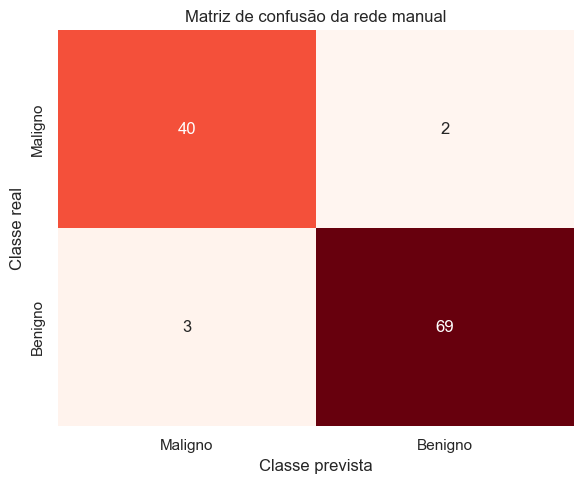

In [11]:
matriz = confusion_matrix(y_teste, previsoes_teste)

plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz,
    annot=True,
    fmt="d",
    cmap="Reds",
    cbar=False,
    xticklabels=["Maligno", "Benigno"],
    yticklabels=["Maligno", "Benigno"],
)
plt.title("Matriz de confusão da rede manual")
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")
plt.tight_layout()
plt.savefig("matriz_confusao_manual.png", dpi=180, bbox_inches="tight")
plt.show()

In [12]:
relatorio = classification_report(
    y_teste,
    previsoes_teste,
    target_names=["Maligno", "Benigno"],
    output_dict=True,
)
display(pd.DataFrame(relatorio).T.round(3))

,precision,recall,f1-score,support
Maligno,0.930,0.952,0.941,42.000
Benigno,0.972,0.958,0.965,72.000
accuracy,0.956,0.956,0.956,0.956
macro avg,0.951,0.955,0.953,114.000
weighted avg,0.957,0.956,0.956,114.000


## 10. Comparação com a implementação Keras

O valor do Keras abaixo corresponde à execução registrada no outro notebook do projeto. As duas redes usam a mesma arquitetura, os mesmos conjuntos de dados e o mesmo tamanho de mini-batch. A principal diferença é o otimizador: a rede manual usa gradiente descendente em mini-batches, enquanto a versão Keras usa Adam.

In [13]:
comparacao = pd.DataFrame(
    {
        "Implementação": ["Manual com NumPy", "Keras"],
        "Acurácia de teste": [acuracia_manual, 0.9474],
        "Atualização": ["Gradiente descendente", "Adam"],
    }
)
comparacao["Acurácia de teste"] = comparacao["Acurácia de teste"].map(lambda valor: f"{valor:.2%}")
display(comparacao)

,Implementação,Acurácia de teste,Atualização
0,Manual com NumPy,95.61%,Gradiente descendente
1,Keras,94.74%,Adam


## 11. Conclusão

Nesta implementação construímos manualmente as principais etapas de uma rede neural. A propagação para frente produziu as probabilidades, a entropia cruzada mediu o erro e o backpropagation calculou os gradientes usados para atualizar pesos e vieses.

A implementação com NumPy exige mais código do que a versão Keras, mas torna visível o papel de cada matriz e de cada derivada. A comparação mostra que uma implementação manual pode atingir um resultado próximo ao obtido por uma biblioteca pronta, embora bibliotecas como Keras ofereçam otimizadores e recursos adicionais.

Este exercício tem finalidade educacional e não deve ser usado para diagnóstico médico.